### **Introducción a la IA Multimodal**


La IA multimodal estudia modelos capaces de **procesar, relacionar y generar información a partir de más de un tipo de señal**. En vez de trabajar solo con texto o solo con imágenes, estos sistemas buscan construir una representación útil cuando intervienen simultáneamente varias fuentes de información, como texto, imagen, audio, video o documentos visuales.

Desde una perspectiva técnica, el problema central no es solo "usar varias entradas", sino resolver al menos cuatro desafíos: **representar** cada modalidad en un espacio computable, **alinear** significados entre modalidades distintas, **fusionar** evidencia heterogénea y, en muchos casos, **generar** una salida útil condicionada por varias señales a la vez.

En este cuaderno la idea no es cubrir todo el estado del arte, sino construir una intuición sólida sobre tres preguntas fundamentales:

1. ¿Cómo se representa una imagen o un texto como vectores comparables?
2. ¿Qué significa poner texto e imagen en un **espacio semántico compartido**?
3. ¿Cómo se conecta un encoder multimodal con sistemas más grandes, como los modelos multimodales de lenguaje?

La secuencia del cuaderno sigue esa lógica:
- primero, una intuición visual sobre representaciones,
- luego, una aproximación didáctica a la alineación texto-imagen,
- después, previews conceptuales de tareas como **captioning** y **VQA**,
- y finalmente, una visión compacta de cómo pensar un **MLLM** como arquitectura modular.



#### **Cómo usar este cuaderno en clase**

- Ejecuta las celdas **en orden**.
- Todo está pensado para correr en **CPU**.
- Las demostraciones "reales" con CLIP o BLIP quedan como **opcionales**.
- Las imágenes se buscan en:
  1. `figures/`
  2. `figuras/`
  3. `/mnt/data/figures/`
  4. `/mnt/data/figuras/`
  5. carpeta actual
  6. `/mnt/data`

Si no se encuentran imágenes, el cuaderno crea tres ejemplos sintéticos: `car`, `cat` y `puppy`.


#### **1. ¿Qué significa "multimodal"?**

Un sistema multimodal integra dos o más modalidades de información, por ejemplo:
- texto,
- imagen,
- audio,
- video,
- documentos visuales,
- series temporales acompañadas de texto.

En términos técnicos, una modalidad es una **fuente estructuralmente distinta de información**. No cambia solo el formato del dato; cambia también la forma de codificarlo, el tipo de ruido que introduce y la semántica que puede aportar. Por ejemplo, una imagen suele aportar evidencia espacial y contextual, mientras que el texto puede aportar precisión semántica, abstracción o instrucciones.

Esto hace que la multimodalidad no sea simplemente "sumar datos", sino aprender a responder preguntas como:
- ¿qué información aporta cada modalidad?,
- ¿qué parte es redundante y qué parte es complementaria?,
- ¿cómo se resuelve un conflicto entre modalidades?,
- ¿qué modalidad domina cuando la evidencia no coincide?,

#### **Ideas clave**
- **Representación:** cómo codificar cada modalidad en vectores o embeddings útiles.
- **Alineamiento:** cómo relacionar modalidades distintas para que objetos o conceptos semánticamente equivalentes queden cercanos.
- **Fusión:** cómo combinar información heterogénea sin perder estructura relevante.
- **Generación:** cómo producir una modalidad a partir de otra, por ejemplo texto desde imagen o audio desde texto.
- **Evaluación:** cómo medir utilidad, error, sesgo, robustez y dependencia entre modalidades.

Una forma útil de pensar el campo es esta:
- **unimodal**: una sola modalidad de entrada
- **multimodal discriminativo**: varias modalidades para clasificar, recuperar o decidir
- **multimodal generativo**: una o más modalidades de entrada para producir otra modalidad de salida.

En la práctica, muchos sistemas modernos combinan ambas familias: primero alinean representaciones y luego usan esa base para recuperar, razonar o generar.

#### **2. Preparación: imports y carga de imágenes**

In [1]:
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np
import textwrap

candidate_dirs = [
    Path("figures"),
    Path("figuras"),
    Path("/mnt/data/figures"),
    Path("/mnt/data/figuras"),
    Path("."),
    Path("/mnt/data"),
]

expected = {
    "car": ["car.png", "car.jpg", "auto.png", "auto.jpg"],
    "cat": ["cat.png", "cat.jpg", "gato.png", "gato.jpg"],
    "puppy": ["puppy.png", "puppy.jpg", "dog.png", "dog.jpg", "cachorro.png", "cachorro.jpg"],
}

def find_image(name):
    for d in candidate_dirs:
        for filename in expected[name]:
            p = d / filename
            if p.exists():
                return p
    return None

def make_synthetic_image(name, size=(384, 256)):
    img = Image.new("RGB", size, color=(245, 245, 245))
    draw = ImageDraw.Draw(img)
    w, h = size

    if name == "car":
        # cielo + suelo
        draw.rectangle([0, 0, w, int(h*0.6)], fill=(255, 205, 120))
        draw.rectangle([0, int(h*0.6), w, h], fill=(120, 120, 120))
        # auto simple
        draw.rounded_rectangle([70, 130, 300, 200], radius=20, fill=(200, 30, 30), outline=(60, 0, 0), width=3)
        draw.polygon([(110,130),(160,95),(250,95),(285,130)], fill=(220,50,50), outline=(60,0,0))
        draw.ellipse([105, 185, 150, 230], fill=(30,30,30))
        draw.ellipse([230, 185, 275, 230], fill=(30,30,30))
        draw.text((10, 10), "synthetic: car", fill=(0,0,0))
    elif name == "cat":
        draw.rectangle([0, 0, w, h], fill=(240, 240, 255))
        # pixel-art simple
        for x in range(90, 290, 20):
            for y in range(70, 210, 20):
                draw.rectangle([x, y, x+18, y+18], fill=(180, 160, 120))
        draw.polygon([(130,90),(155,45),(180,90)], fill=(160,140,100))
        draw.polygon([(200,90),(225,45),(250,90)], fill=(160,140,100))
        draw.ellipse([145, 120, 165, 140], fill=(0,0,0))
        draw.ellipse([215, 120, 235, 140], fill=(0,0,0))
        draw.text((10, 10), "synthetic: cat", fill=(0,0,0))
    elif name == "puppy":
        draw.rectangle([0, 0, w, h], fill=(235, 245, 255))
        draw.rectangle([0, int(h*0.72), w, h], fill=(245, 245, 245))
        draw.ellipse([110, 90, 260, 210], fill=(180, 120, 90), outline=(80,50,30), width=3)
        draw.ellipse([220, 110, 310, 180], fill=(180, 120, 90), outline=(80,50,30), width=3)
        draw.ellipse([250, 130, 260, 140], fill=(0,0,0))
        draw.ellipse([130, 200, 150, 230], fill=(120,80,50))
        draw.ellipse([200, 200, 220, 230], fill=(120,80,50))
        draw.text((10, 10), "synthetic: puppy", fill=(0,0,0))
    return img

image_paths = {name: find_image(name) for name in expected}
images = {}

for name, path in image_paths.items():
    if path is not None:
        images[name] = Image.open(path).convert("RGB")
    else:
        images[name] = make_synthetic_image(name)

print("Rutas detectadas:")
for name, path in image_paths.items():
    print(f" - {name}: {path if path is not None else 'sin archivo; usando imagen sintética'}")

Rutas detectadas:
 - car: figuras\car.png
 - cat: figuras\cat.png
 - puppy: figuras\puppy.png


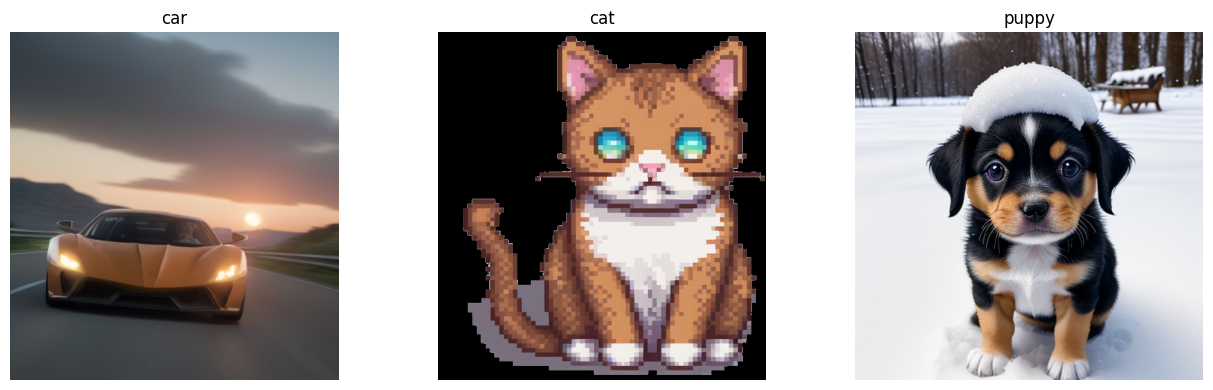

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

#### **3. De convoluciones a Vision Transformers (ViT)**

Una forma de entrar a la multimodalidad es mostrar primero cómo un encoder visual moderno puede tratar una imagen como una secuencia de **patches** o **tokens visuales**.

##### **Idea central**
- En CNNs, la imagen se procesa por convoluciones locales.
- En ViT, la imagen se divide en parches fijos.
- Cada parche se proyecta a un embedding.
- Luego, el modelo procesa la secuencia de embeddings de manera análoga a texto.

Esto prepara la intuición para conectar visión con lenguaje: si ambos terminan representados como vectores, ya podemos hablar de **alineamiento**.


In [3]:
def patchify(img, patch_size=64): 
    arr = np.array(img)
    h, w, c = arr.shape
    h2 = (h // patch_size) * patch_size
    w2 = (w // patch_size) * patch_size
    arr = arr[:h2, :w2]

    patches = []
    coords = []
    #recorre la imagen en bloques de 64x64
    #guarda cada bloque en patches
    #guarda la posición (x, y) en coords
    for y in range(0, h2, patch_size): 
        for x in range(0, w2, patch_size):
            patches.append(arr[y:y+patch_size, x:x+patch_size])
            coords.append((x, y))
    return arr, patches, coords

cat_img = images["cat"]
cat_cropped, cat_patches, cat_coords = patchify(cat_img, patch_size=64)

print("Tamaño original:", np.array(cat_img).shape)
print("Tamaño recortado para patching:", cat_cropped.shape)
print("Número de parches:", len(cat_patches))


Tamaño original: (618, 583, 3)
Tamaño recortado para patching: (576, 576, 3)
Número de parches: 81


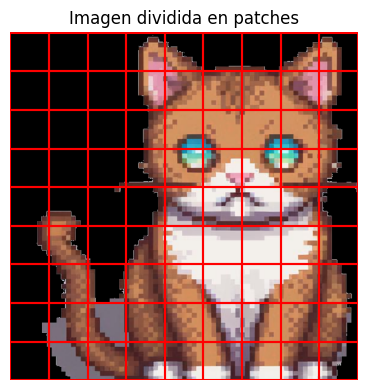

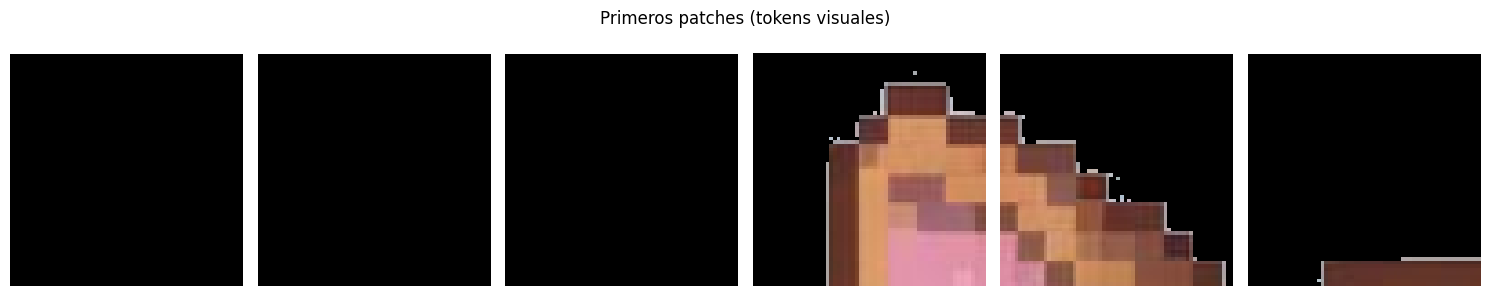

In [4]:
arr = cat_cropped.copy()
patch_size = 64

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(arr)
for x, y in cat_coords:
    ax.add_patch(plt.Rectangle((x, y), patch_size, patch_size, fill=False, edgecolor="red", linewidth=1.5))
ax.set_title("Imagen dividida en patches")
ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, min(6, len(cat_patches)), figsize=(15, 3))
for ax, patch in zip(axes, cat_patches[:6]):
    ax.imshow(patch)
    ax.axis("off")
plt.suptitle("Primeros patches (tokens visuales)")
plt.tight_layout()
plt.show()


#### **Actividad guiada**

1. Cambia `patch_size` a 32, 48 y 96.
2. Observa cómo cambia el número de tokens visuales.
3. Discute: ¿qué gana y qué pierde el modelo con patches más pequeños o más grandes?


In [6]:
cat_cropped, cat_patches, cat_coords = patchify(cat_img, patch_size=32)

print("Tamaño original:", np.array(cat_img).shape)
print("Tamaño recortado para patching:", cat_cropped.shape)
print("Número de parches:", len(cat_patches))


Tamaño original: (618, 583, 3)
Tamaño recortado para patching: (608, 576, 3)
Número de parches: 342


In [6]:
cat_cropped, cat_patches, cat_coords = patchify(cat_img, patch_size=32)

print("Tamaño original:", np.array(cat_img).shape)
print("Tamaño recortado para patching:", cat_cropped.shape)
print("Número de parches:", len(cat_patches))


Tamaño original: (618, 583, 3)
Tamaño recortado para patching: (608, 576, 3)
Número de parches: 342


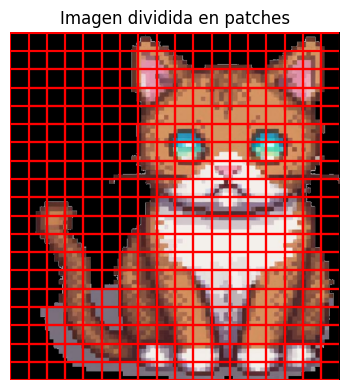

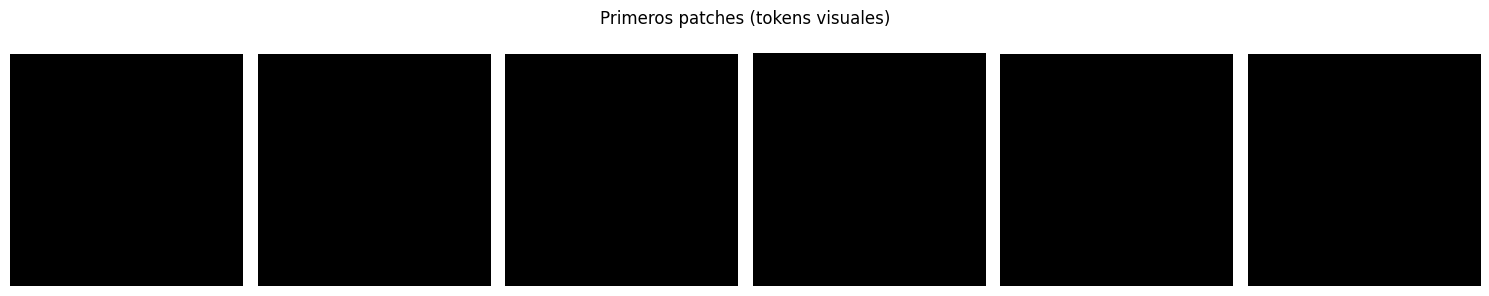

In [7]:
arr = cat_cropped.copy()
patch_size = 64

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(arr)
for x, y in cat_coords:
    ax.add_patch(plt.Rectangle((x, y), patch_size, patch_size, fill=False, edgecolor="red", linewidth=1.5))
ax.set_title("Imagen dividida en patches")
ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, min(6, len(cat_patches)), figsize=(15, 3))
for ax, patch in zip(axes, cat_patches[:6]):
    ax.imshow(patch)
    ax.axis("off")
plt.suptitle("Primeros patches (tokens visuales)")
plt.tight_layout()
plt.show()

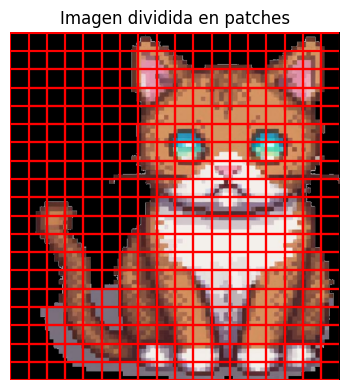

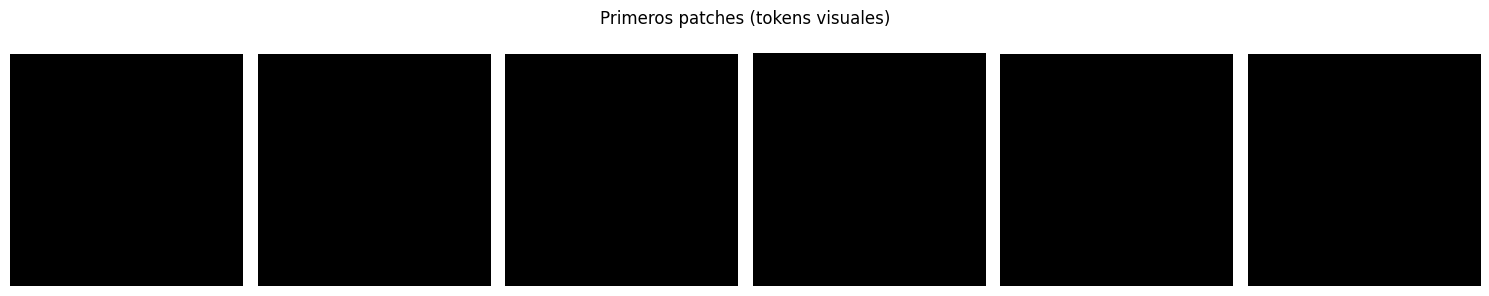

In [7]:
arr = cat_cropped.copy()
patch_size = 64

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(arr)
for x, y in cat_coords:
    ax.add_patch(plt.Rectangle((x, y), patch_size, patch_size, fill=False, edgecolor="red", linewidth=1.5))
ax.set_title("Imagen dividida en patches")
ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, min(6, len(cat_patches)), figsize=(15, 3))
for ax, patch in zip(axes, cat_patches[:6]):
    ax.imshow(patch)
    ax.axis("off")
plt.suptitle("Primeros patches (tokens visuales)")
plt.tight_layout()
plt.show()

In [8]:
cat_cropped, cat_patches, cat_coords = patchify(cat_img, patch_size=48)

print("Tamaño original:", np.array(cat_img).shape)
print("Tamaño recortado para patching:", cat_cropped.shape)
print("Número de parches:", len(cat_patches))


Tamaño original: (618, 583, 3)
Tamaño recortado para patching: (576, 576, 3)
Número de parches: 144


In [8]:
cat_cropped, cat_patches, cat_coords = patchify(cat_img, patch_size=48)

print("Tamaño original:", np.array(cat_img).shape)
print("Tamaño recortado para patching:", cat_cropped.shape)
print("Número de parches:", len(cat_patches))


Tamaño original: (618, 583, 3)
Tamaño recortado para patching: (576, 576, 3)
Número de parches: 144


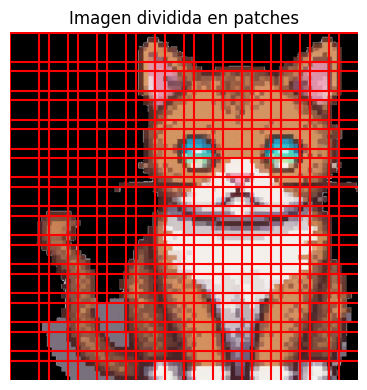

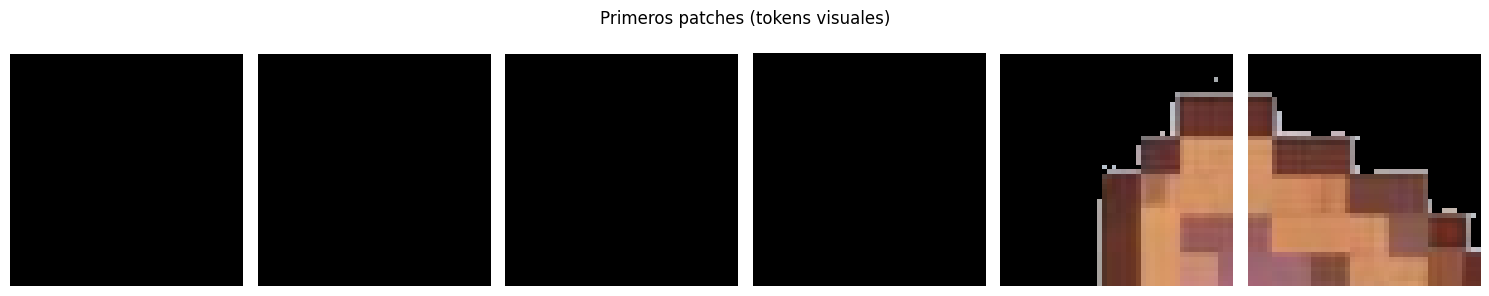

In [9]:
arr = cat_cropped.copy()
patch_size = 64

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(arr)
for x, y in cat_coords:
    ax.add_patch(plt.Rectangle((x, y), patch_size, patch_size, fill=False, edgecolor="red", linewidth=1.5))
ax.set_title("Imagen dividida en patches")
ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, min(6, len(cat_patches)), figsize=(15, 3))
for ax, patch in zip(axes, cat_patches[:6]):
    ax.imshow(patch)
    ax.axis("off")
plt.suptitle("Primeros patches (tokens visuales)")
plt.tight_layout()
plt.show()

In [10]:
cat_cropped, cat_patches, cat_coords = patchify(cat_img, patch_size=96)

print("Tamaño original:", np.array(cat_img).shape)
print("Tamaño recortado para patching:", cat_cropped.shape)
print("Número de parches:", len(cat_patches))


Tamaño original: (618, 583, 3)
Tamaño recortado para patching: (576, 576, 3)
Número de parches: 36


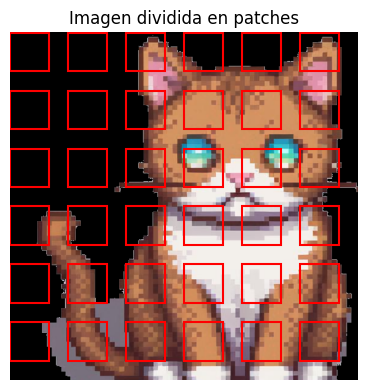

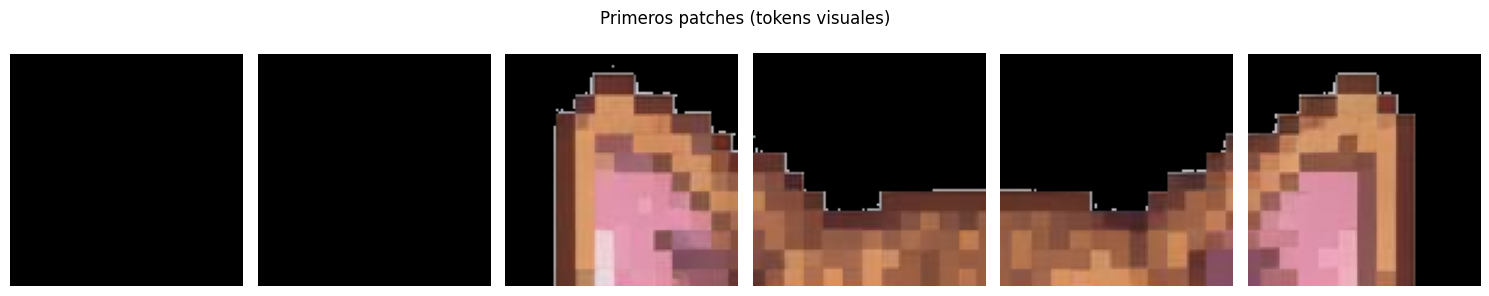

In [11]:
arr = cat_cropped.copy()
patch_size = 64

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(arr)
for x, y in cat_coords:
    ax.add_patch(plt.Rectangle((x, y), patch_size, patch_size, fill=False, edgecolor="red", linewidth=1.5))
ax.set_title("Imagen dividida en patches")
ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, min(6, len(cat_patches)), figsize=(15, 3))
for ax, patch in zip(axes, cat_patches[:6]):
    ax.imshow(patch)
    ax.axis("off")
plt.suptitle("Primeros patches (tokens visuales)")
plt.tight_layout()
plt.show()

#### **4. Representaciones conjuntas texto-imagen: intuición tipo CLIP**

Antes de ejecutar un modelo real, es útil mostrar una versión didáctica del problema.

La idea es simple:
- cada imagen tendrá una semántica aproximada,
- cada texto se convertirá en una representación vectorial simple,
- luego compararemos texto e imagen con similitud coseno.

Esto **no es CLIP real**, pero ayuda a entender:
- espacio compartido,
- cercanía semántica,
- recuperación cruzada.

La intuición matemática detrás de este bloque es importante: si texto e imagen pueden proyectarse a un **mismo espacio vectorial**, entonces comparar ambas modalidades deja de ser un problema "entre formatos" y pasa a ser un problema geométrico. Dos elementos cercanos en ese espacio deberían corresponder a significados relacionados.

En un sistema real tipo CLIP:
- un **encoder visual** transforma la imagen en un embedding,
- un **encoder textual** transforma la descripción en otro embedding,
- ambos se entrenan para que pares correctos texto-imagen queden cerca y pares incorrectos queden lejos.

Aquí simplificamos esa idea para hacer visible el principio central:
- no buscamos una clasificación cerrada,
- buscamos **alineación semántica** entre modalidades.

Eso permite introducir naturalmente tareas como:
- **image retrieval** a partir de texto,
- **text retrieval** a partir de imagen,
- ranking por similitud,
- zero-shot classification vía prompts textuales.



In [12]:
captions = {
    "car": "A sports car driving on the road at sunset",
    "cat": "A pixelated image of a cute cat",
    "puppy": "A puppy playing in the snow",
}

vocab = [
    "car", "road", "sunset",
    "cat", "pixelated", "cute",
    "puppy", "dog", "snow",
]

vocab_index = {w: i for i, w in enumerate(vocab)}

def text_embedding(text):
    vec = np.zeros(len(vocab), dtype=float)
    t = text.lower()
    for w in vocab:
        if w in t:
            vec[vocab_index[w]] += 1.0
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec

image_semantics = {
    "car": ["car", "road", "sunset"],
    "cat": ["cat", "pixelated", "cute"],
    "puppy": ["puppy", "dog", "snow"],
}

def image_embedding(image_name):
    vec = np.zeros(len(vocab), dtype=float)
    for w in image_semantics[image_name]:
        vec[vocab_index[w]] += 1.0
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec

img_embs = {name: image_embedding(name) for name in images}
txt_embs = {name: text_embedding(txt) for name, txt in captions.items()}


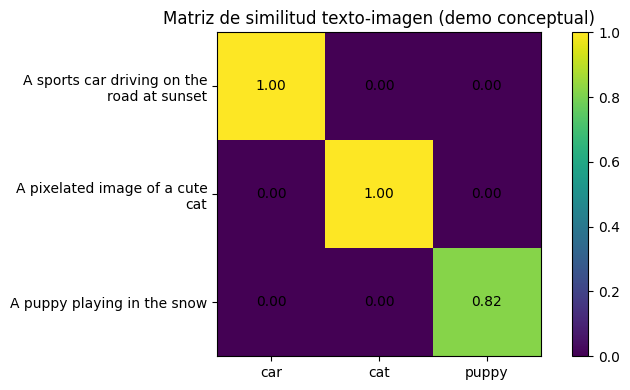

In [13]:
def cosine(a, b):
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

img_names = list(images.keys())
txt_names = list(captions.keys())

sim_matrix = np.zeros((len(txt_names), len(img_names)))
for i, tname in enumerate(txt_names):
    for j, iname in enumerate(img_names):
        sim_matrix[i, j] = cosine(txt_embs[tname], img_embs[iname])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(sim_matrix)
ax.set_xticks(range(len(img_names)))
ax.set_xticklabels(img_names)
ax.set_yticks(range(len(txt_names)))
ax.set_yticklabels([textwrap.fill(captions[t], 28) for t in txt_names])

for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha="center", va="center")

ax.set_title("Matriz de similitud texto-imagen (demo conceptual)")
plt.colorbar(im, ax=ax, fraction=0.045)
plt.tight_layout()
plt.show()


In [14]:
def retrieve_image(query_text, top_k=3):
    q = text_embedding(query_text)
    scores = []
    for iname in img_names:
        s = cosine(q, img_embs[iname])
        scores.append((iname, s))
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

queries = [
    "a cute pixelated cat",
    "a dog in the snow",
    "a fast car on the road at sunset",
]

for q in queries:
    print("\nConsulta:", q)
    for iname, score in retrieve_image(q):
        print(f"  {iname:>5s}  score={score:.2f}")



Consulta: a cute pixelated cat
    cat  score=1.00
    car  score=0.00
  puppy  score=0.00

Consulta: a dog in the snow
  puppy  score=0.82
    car  score=0.00
    cat  score=0.00

Consulta: a fast car on the road at sunset
    car  score=1.00
    cat  score=0.00
  puppy  score=0.00


#### **Preguntas para discutir**
- ¿Qué se gana al poner imagen y texto en un mismo espacio?
- ¿Qué limitaciones tiene esta aproximación didáctica?
- ¿Qué cambiaría al usar millones de pares imagen-texto reales?


#### **5. Demostración opcional con CLIP real**

In [7]:
import sys
print(sys.executable)

/opt/conda/bin/python


In [4]:
!pip install transformers accelerate sentencepiece torch

In [5]:
from transformers import CLIPModel
print("CLIP listo")

CLIP listo


In [8]:
# !pip -q install transformers accelerate sentencepiece

clip_ready = False
try:
    import torch
    from transformers import CLIPProcessor, CLIPModel
    clip_ready = True
except Exception as e:
    print("CLIP no disponible todavía:", e)

if clip_ready:
    model_id = "openai/clip-vit-base-patch32"
    processor = CLIPProcessor.from_pretrained(model_id)
    model = CLIPModel.from_pretrained(model_id)

    clip_images = [images[k] for k in ["car", "cat", "puppy"]]
    clip_texts = [captions[k] for k in ["car", "cat", "puppy"]]

    batch = processor(text=clip_texts, images=clip_images, return_tensors="pt", padding=True)

    with torch.no_grad():
        outputs = model(**batch)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1).cpu().numpy()

    print("Matriz de probabilidades (imagen x texto):")
    print(np.round(probs, 3))


ValueError: Unrecognized image processor in openai/clip-vit-base-patch32. Should have a `image_processor_type` key in its preprocessor_config.json of config.json, or one of the following `model_type` keys in its config.json: aimv2, aimv2_vision_model, align, altclip, aria, aya_vision, beit, bit, blip, blip-2, bridgetower, chameleon, chinese_clip, chmv2, clip, clipseg, cohere2_vision, colpali, colqwen2, conditional_detr, convnext, convnextv2, cvt, data2vec-vision, deepseek_vl, deepseek_vl_hybrid, deformable_detr, deit, depth_anything, depth_pro, detr, dinat, dinov2, dinov3_vit, donut-swin, dpt, edgetam, efficientloftr, efficientnet, emu3, eomt, eomt_dinov3, ernie4_5_vl_moe, flava, florence2, focalnet, fuyu, gemma3, gemma3n, gemma4, git, glm46v, glm4v, glm_image, glpn, got_ocr2, grounding-dino, groupvit, hiera, idefics, idefics2, idefics3, ijepa, imagegpt, instructblip, internvl, janus, kosmos-2, kosmos-2.5, layoutlmv2, layoutlmv3, layoutxlm, levit, lfm2_vl, lightglue, lighton_ocr, llama

#### **6. Preview opcional: captioning con BLIP**

Esto sirve para explicar la diferencia entre:
- **recuperación/matching** (tipo CLIP),
- y **generación** (tipo captioning).

En recuperación, el sistema decide qué texto e imagen son compatibles dentro de un espacio compartido. En captioning, en cambio, el sistema debe **producir secuencias lingüísticas** condicionadas por la información visual. El objetivo deja de ser solo medir similitud y pasa a ser modelar una distribución del tipo:

**P(texto | imagen)**

Eso cambia el problema de forma importante:
- ahora importa el orden de las palabras,
- importa la fluidez lingüística,
- importa qué detalles visuales se consideran salientes,
- e importan los sesgos del modelo al describir escenas.

Modelos como BLIP son útiles en clase porque permiten mostrar que la visión-lenguaje no es solo "alinear embeddings", sino también combinar:
- un componente de **entendimiento visual**,
- un componente de **lenguaje autoregresivo o encoder-decoder**,
- y un mecanismo de entrenamiento que conecte ambos de manera estable.

Esta sección ayuda a distinguir dos familias de tareas:
- **matching/retrieval**: encontrar correspondencias
- **captioning/generation**: construir descripciones nuevas a partir de contenido visual.

In [ ]:
# !pip -q install transformers accelerate sentencepiece

blip_ready = False
try:
    import torch
    from transformers import BlipProcessor, BlipForConditionalGeneration
    blip_ready = True
except Exception as e:
    print("BLIP no disponible todavía:", e)

if blip_ready:
    model_id = "Salesforce/blip-image-captioning-base"
    processor = BlipProcessor.from_pretrained(model_id)
    model = BlipForConditionalGeneration.from_pretrained(model_id)

    sample = images["car"]
    inputs = processor(images=sample, return_tensors="pt")

    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=30)

    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    print("Caption generado:", caption)


#### **7. Preview opcional: VQA conceptual**

Antes de usar un modelo VQA real, es importante mostrar la lógica general:
- una imagen aporta contexto visual,
- la pregunta dirige la búsqueda de información relevante,
- el sistema responde condicionado por ambas entradas.

La dificultad de VQA no está solo en "ver la imagen" ni solo en "entender la pregunta", sino en **componer ambas señales de manera condicional**. La misma imagen puede requerir respuestas distintas según el tipo de pregunta:
- conteo,
- reconocimiento de objetos,
- atributos,
- relaciones espaciales,
- inferencias de sentido común.

Por eso VQA se puede presentar como una forma simple de razonamiento multimodal:
1. la imagen ofrece evidencia visual,
2. la pregunta actúa como filtro o consulta semántica,
3. el sistema selecciona o construye una respuesta compatible con ambas.

A nivel conceptual, esta tarea permite discutir varios retos importantes:
- **grounding**: qué parte de la imagen sustenta la respuesta,
- **atención condicionada**: cómo cambia la evidencia relevante según la pregunta,
- **sesgo del dataset**: cuándo el sistema responde por atajos lingüísticos en lugar de razonar visualmente,
- **formato de salida**: clasificación cerrada vs respuesta libre.

VQA es muy útil porque conecta percepción, lenguaje y razonamiento en un solo ejemplo.


In [ ]:
visual_facts = {
    "car": {
        "objects": ["car", "road", "sunset"],
        "scene": "A sports car driving on the road at sunset.",
        "weather": "clear sky with sunset light",
        "dominant_topic": "transportation"
    },
    "cat": {
        "objects": ["cat", "pixel-art", "cute"],
        "scene": "A pixelated image of a cute cat.",
        "weather": "not applicable",
        "dominant_topic": "animal"
    },
    "puppy": {
        "objects": ["puppy", "snow", "park"],
        "scene": "A puppy sitting in the snow.",
        "weather": "snowy",
        "dominant_topic": "animal"
    },
}

def vqa_demo(image_name, question):
    q = question.lower().strip()
    facts = visual_facts[image_name]

    if "what" in q and ("see" in q or "image" in q or "picture" in q):
        return facts["scene"]
    if "animal" in q:
        return "Yes." if facts["dominant_topic"] == "animal" else "No."
    if "weather" in q or "snow" in q:
        return f"Weather/scene condition: {facts['weather']}."
    if "objects" in q or "things" in q:
        return "I can identify: " + ", ".join(facts["objects"]) + "."
    if "car" in q:
        return "Yes, there is a car." if "car" in facts["objects"] else "No, I do not see a car."
    return "I need a more specific question."

sample_questions = [
    "What do you see in this picture?",
    "What objects are visible?",
    "Is there an animal?",
    "What is the weather?",
    "Is there a car?",
]

for name in ["car", "cat", "puppy"]:
    print("\n" + "="*55)
    print("Imagen:", name)
    for q in sample_questions:
        print("Q:", q)
        print("A:", vqa_demo(name, q))


#### **8. MLLM en una sola idea**

Un modelo multimodal grande puede verse como una cadena de módulos:

**modalidad -> encoder especializado -> embeddings -> adaptador/puente -> LLM -> salida textual**

En esta vista modular, cada parte cumple una función distinta:

- **Encoder especializado:** transforma una modalidad cruda en representaciones útiles.
  - imagen -> encoder visual,
  - audio -> encoder acústico,
  - documento -> encoder visual-textual,
  - video -> encoder espacio-temporal.

- **Embeddings:** representan la señal en una forma numérica comprimida que preserve información semántica.

- **Adaptador o puente multimodal:** convierte esas representaciones a un formato compatible con el modelo lingüístico. Este bloque puede ser un proyector lineal, un resampler, cross-attention, tokens aprendidos o una combinación de varios mecanismos.

- **LLM:** recibe una secuencia enriquecida y produce una salida textual, ya sea explicación, respuesta, resumen o instrucción.

La idea importante es que muchos MLLM no "ven" directamente una imagen como lo hace una CNN clásica. Más bien:
1. un encoder visual extrae rasgos,
2. un puente los traduce a tokens o embeddings utilizables,
3. el LLM opera sobre esa interfaz.

Esto permite explicar por qué el diseño del **adapter** es tan importante:
- controla cuánta información visual pasa,
- cómo se integra con el contexto textual,
- y qué tan bien se preserva el grounding entre modalidades.

En clase, este esquema ayuda a pasar de ejemplos concretos como CLIP, captioning o VQA a una visión más general de arquitecturas multimodales modernas.


In [ ]:
def mllm_router(modality, payload=None):
    if modality == "text":
        return {"encoder": "Text encoder/tokenizer", "output": "text embeddings"}
    elif modality == "image":
        return {"encoder": "Vision encoder (ViT)", "output": "visual embeddings"}
    elif modality == "audio":
        return {"encoder": "Audio encoder", "output": "audio embeddings"}
    elif modality == "video":
        return {"encoder": "Video encoder (frames + temporal modeling)", "output": "video embeddings"}
    else:
        return {"encoder": "Unknown", "output": "N/A"}

for m in ["text", "image", "audio", "video"]:
    step = mllm_router(m)
    print(f"{m:>5s} -> {step['encoder']} -> {step['output']} -> adapter/Q-Former -> LLM -> texto")


#### **Pregunta final para discusión**

¿Qué problema real de tu dominio podría formularse como:
- clasificación multimodal,
- recuperación cruzada,
- captioning,
- VQA,
- o asistente multimodal?.


#### **9. Encargo breve para la próxima semana**

1. Leer un survey de introducción al aprendizaje multimodal.
2. Revisar un paper clásico de alineamiento visual-semántico.
3. Proponer dos ideas tentativas de trabajo integrador.
4. Identificar qué modalidad principal usaría cada propuesta.


#### **10. Lecturas sugeridas para Semana 1**

##### **Obligatorias**
- Baltrušaitis, Ahuja, Morency - [*Multimodal Machine Learning: A Survey and Taxonomy*](https://arxiv.org/abs/1705.09406)
- Radford et al. - [*Learning Transferable Visual Models From Natural Language Supervision (CLIP)*](https://arxiv.org/abs/2103.00020)

##### **Recomendadas**
- Karpathy & Fei-Fei - [*Deep Visual-Semantic Alignments for Generating Image Descriptions*](https://arxiv.org/abs/1412.2306)
- Antol et al. - [*VQA: Visual Question Answering*](https://arxiv.org/abs/1505.00468)
- Li et al. - [*BLIP: Bootstrapping Language-Image Pre-training for Unified Vision-Language Understanding and Generation*](https://arxiv.org/abs/2201.12086)

##### **Sugerencia de lectura**
- Empieza por el **survey** para fijar vocabulario y taxonomía.
- Luego lee **CLIP** para entender alineación texto-imagen y aprendizaje contrastivo.
- Finalmente revisa **VQA**, **captioning** y **BLIP** como ejemplos de tareas multimodales con distintos objetivos.
